# Fases 1 a 3 - Corpus, limpieza y baseline SVM

El notebook usa la base reusable de `src/` y deja listo el baseline clasico sobre una muestra estratificada real.

In [25]:
from pathlib import Path
import sys

import pandas as pd

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
except ImportError:
    plt = None
    sns = None

RAIZ_PROYECTO = Path.cwd().resolve().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd()
if str(RAIZ_PROYECTO) not in sys.path:
    sys.path.insert(0, str(RAIZ_PROYECTO))

import importlib
import src.property_text_pipeline
import src.evaluacion_modelos
importlib.reload(src.property_text_pipeline)
importlib.reload(src.evaluacion_modelos)

from src.artefactos_modelos import guardar_modelo_svm
from src.corpus_inmuebles import construir_tabla_distribucion_clases, preparar_corpus_para_modelado
from src.evaluacion_modelos import (
    construir_matriz_confusion_tabla,
    construir_reporte_clasificacion,
    construir_tabla_metricas,
    dibujar_matriz_confusion_profesional,
    evaluar_svm_con_validacion_cruzada,
)
from src.infraestructura_cpu import configurar_torch_cpu, relevar_hardware, sugerir_tamanio_muestra
from src.property_text_pipeline import (
    COLUMNA_OBJETIVO,
    COLUMNA_TEXTO_LIMPIO,
    TERMINOS_CLAVE,
    construir_auditoria_terminos,
    construir_ejemplos_limpieza,
    entrenar_modelo_base_svm,
    entrenar_modelo_bayes,
    entrenar_modelo_logistica,
)

In [26]:
RUTA_DATOS = RAIZ_PROYECTO / 'data' / 'entrenamiento.csv'
SEMILLA = 42
TAMANIO_TEST = 0.2

resumen = relevar_hardware()
configurar_torch_cpu()
tamanio_muestra = sugerir_tamanio_muestra(resumen.memoria_disponible_gb)
print(f'Tamanio de muestra sugerido: {tamanio_muestra}')

df_muestra, df_entrenamiento, df_prueba = preparar_corpus_para_modelado(
    ruta_datos=RUTA_DATOS,
    tamanio_muestra=tamanio_muestra,
    tamanio_test=TAMANIO_TEST,
    semilla=SEMILLA,
)

print(f'Registros en la muestra: {len(df_muestra)}')
construir_tabla_distribucion_clases(df_muestra)


Tamanio de muestra sugerido: 15000
Registros en la muestra: 30000


,clase,cantidad,porcentaje
0,Departamento,12843,42.81
1,Casa,9707,32.36
2,PH,7450,24.83


In [27]:
ratio_vacios = (df_muestra[COLUMNA_TEXTO_LIMPIO].str.len() == 0).mean()
print(f'Proporcion de texto limpio vacio: {ratio_vacios:.4f}')

ejemplos = construir_ejemplos_limpieza(df_muestra)
auditoria = construir_auditoria_terminos(df_muestra, terminos_clave=TERMINOS_CLAVE)

display(ejemplos)
display(auditoria)


Proporcion de texto limpio vacio: 0.0001


,description,texto_limpio
345,Excelente PH en impecable estado APTO PROFESIO...,excelente ph impecable estado apto profesional...
6695,Venta de Departamento 2 ambientes a la calle e...,venta departamento 2_ambientes calle playa gra...
4322,SAN RAFAEL AL LAGO. OPORTUNIDAD DE PRECIO. ACE...,san rafael al lago oportunidad precio acepta p...
14429,Corredor Responsable: FRANCO SAVONE - CSI 6499...,corredor responsable franco savone csi 6499con...
17383,Estupendo PH ubicado en Malabia Y Guatemala. 3...,estupendo ph ubicado malabia guatemala 3_ambie...


,termino,coincidencias_original,coincidencias_limpio
0,expensas,7826,7826
1,balcon,9403,9403
2,entrada independiente,928,933


In [28]:
# Test de limpieza
import importlib
import src.property_text_pipeline
importlib.reload(src.property_text_pipeline)
from src.property_text_pipeline import limpiar_texto
test_text = "Semipiso premium de 78mt2, centrico, amplio y luminoso"
print(f"Original: {test_text}")
limpio = limpiar_texto(test_text)
print(f"Limpio: {limpio}")
print(f"Repr: {repr(limpio)}")

Original: Semipiso premium de 78mt2, centrico, amplio y luminoso
Limpio: semipiso premium 78_m2 centrico amplio luminoso
Repr: 'semipiso premium 78_m2 centrico amplio luminoso'


In [29]:
import re
text = "semipiso premium de 78mt2, centrico, amplio y luminoso"
print("Before fusion:", repr(text))
from src.property_text_pipeline import _fusion_semantica
after = _fusion_semantica(text)
print("After fusion:", repr(after))
aggressive = re.sub(r'[^a-záéíóúñ0-9_ ]', ' ', after)
print("After aggressive:", repr(aggressive))
final = re.sub(r'\s+', ' ', aggressive).strip()
print("Final:", repr(final))

Before fusion: 'semipiso premium de 78mt2, centrico, amplio y luminoso'
After fusion: 'semipiso premium de 78_m2, centrico, amplio y luminoso'
After aggressive: 'semipiso premium de 78_m2  centrico  amplio y luminoso'
Final: 'semipiso premium de 78_m2 centrico amplio y luminoso'


              precision    recall  f1-score   support

        Casa     0.9247    0.8670    0.8949      2707
Departamento     0.9823    0.9298    0.9553      5843
          PH     0.3985    0.8244    0.5373       450

    accuracy                         0.9057      9000
   macro avg     0.7685    0.8738    0.7959      9000
weighted avg     0.9358    0.9057    0.9163      9000



,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,0.9057,0.7685,0.8738,0.7959,0.9358,0.9057,0.9163


,metrica,media,desvio
0,accuracy,0.8800,0.0031
1,precision_macro,0.8695,0.0036
2,recall_macro,0.8640,0.0028
3,f1_macro,0.8663,0.0029
4,f1_weighted,0.8790,0.0029


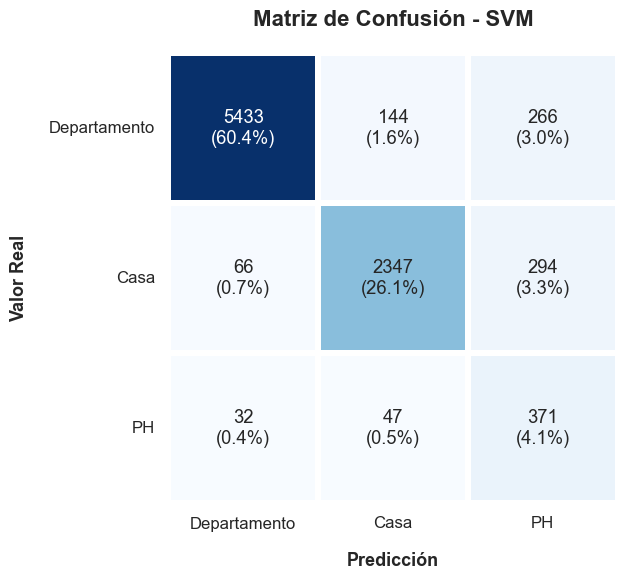

In [30]:
modelo_svm = entrenar_modelo_base_svm(
    df_entrenamiento,
    df_entrenamiento[COLUMNA_OBJETIVO],
    columna_texto=COLUMNA_TEXTO_LIMPIO,
)
predicciones_svm = modelo_svm.predict(df_prueba[COLUMNA_TEXTO_LIMPIO])

print(construir_reporte_clasificacion(df_prueba[COLUMNA_OBJETIVO], predicciones_svm))
display(construir_tabla_metricas(df_prueba[COLUMNA_OBJETIVO], predicciones_svm))
display(evaluar_svm_con_validacion_cruzada(df_muestra))

dibujar_matriz_confusion_profesional(
    df_prueba[COLUMNA_OBJETIVO],
    predicciones_svm,
    etiquetas_ordenadas=['Departamento', 'Casa', 'PH'],
    titulo='Matriz de Confusión - SVM'
)

=== Modelo Naive Bayes ===
              precision    recall  f1-score   support

        Casa     0.8486    0.7950    0.8209      2707
Departamento     0.9802    0.7888    0.8742      5843
          PH     0.1879    0.7356    0.2993       450

    accuracy                         0.7880      9000
   macro avg     0.6722    0.7731    0.6648      9000
weighted avg     0.9010    0.7880    0.8294      9000



,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,0.788,0.6722,0.7731,0.6648,0.901,0.788,0.8294


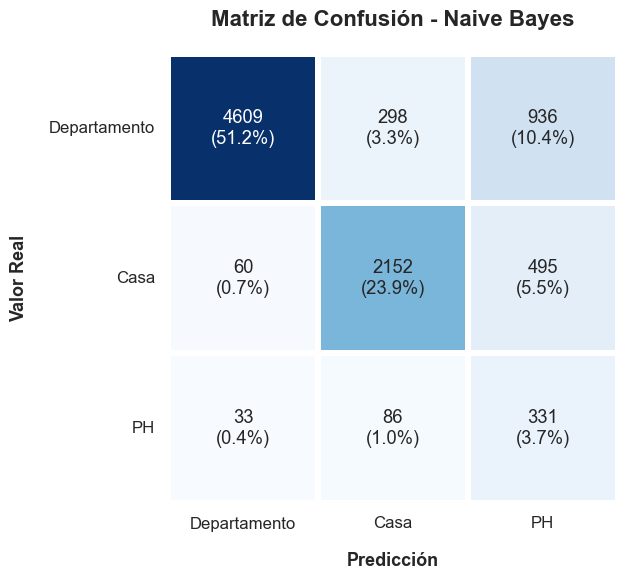

In [31]:
# Entrenamiento y evaluación del modelo Naive Bayes
modelo_bayes = entrenar_modelo_bayes(
    df_entrenamiento,
    df_entrenamiento[COLUMNA_OBJETIVO],
    columna_texto=COLUMNA_TEXTO_LIMPIO,
)
predicciones_bayes = modelo_bayes.predict(df_prueba[COLUMNA_TEXTO_LIMPIO])

print("=== Modelo Naive Bayes ===")
print(construir_reporte_clasificacion(df_prueba[COLUMNA_OBJETIVO], predicciones_bayes))
display(construir_tabla_metricas(df_prueba[COLUMNA_OBJETIVO], predicciones_bayes))

dibujar_matriz_confusion_profesional(
    df_prueba[COLUMNA_OBJETIVO],
    predicciones_bayes,
    etiquetas_ordenadas=['Departamento', 'Casa', 'PH'],
    titulo='Matriz de Confusión - Naive Bayes'
)

=== Modelo Regresión Logística ===
              precision    recall  f1-score   support

        Casa     0.9369    0.8774    0.9061      2707
Departamento     0.9819    0.9377    0.9593      5843
          PH     0.4203    0.8267    0.5573       450

    accuracy                         0.9140      9000
   macro avg     0.7797    0.8806    0.8076      9000
weighted avg     0.9403    0.9140    0.9232      9000



,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,0.914,0.7797,0.8806,0.8076,0.9403,0.914,0.9232


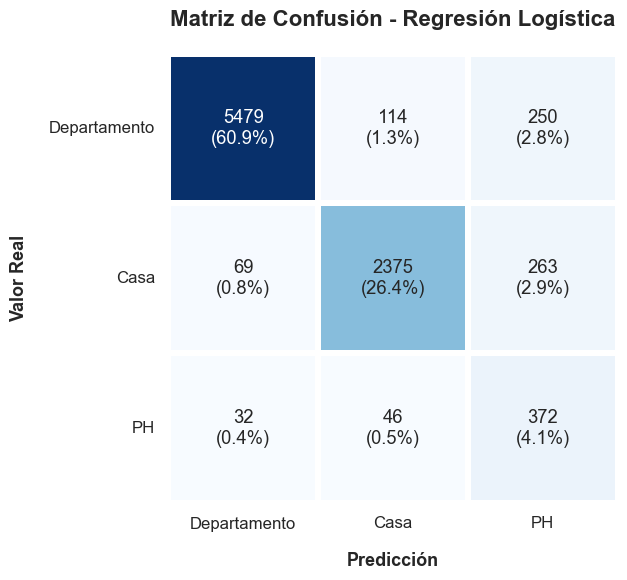

In [32]:
# Entrenamiento y evaluación del modelo de Regresión Logística
modelo_logistica = entrenar_modelo_logistica(
    df_entrenamiento,
    df_entrenamiento[COLUMNA_OBJETIVO],
    columna_texto=COLUMNA_TEXTO_LIMPIO,
)
predicciones_logistica = modelo_logistica.predict(df_prueba[COLUMNA_TEXTO_LIMPIO])

print("=== Modelo Regresión Logística ===")
print(construir_reporte_clasificacion(df_prueba[COLUMNA_OBJETIVO], predicciones_logistica))
display(construir_tabla_metricas(df_prueba[COLUMNA_OBJETIVO], predicciones_logistica))

dibujar_matriz_confusion_profesional(
    df_prueba[COLUMNA_OBJETIVO],
    predicciones_logistica,
    etiquetas_ordenadas=['Departamento', 'Casa', 'PH'],
    titulo='Matriz de Confusión - Regresión Logística'
)

In [33]:
ruta_modelo = guardar_modelo_svm(modelo_svm)
print(f'Modelo SVM guardado en: {ruta_modelo}')


Modelo SVM guardado en: /home/juan/Documentos/Ciencia de Datos/08 _Seminario de procesamiento de lenguaje natural/TFI/nlp_trabajo_final/artifacts/modelo_svm.joblib


## Análisis de Data Leakage
Calculamos la cantidad de registros que contienen palabras clave que delatan su clase directamente en la descripción original.


In [34]:
import pandas as pd
import re

keywords = {
    'Casa': r'\bcasa\b',
    'Departamento': r'\b(?:departamento|depto|dpto)\b',
    'PH': r'\b(?:ph|horizontal)\b'
}

resultados = []

for clase, patron in keywords.items():
    df_clase = df_muestra[df_muestra['property_type'] == clase]
    total = len(df_clase)
    
    con_palabra = df_clase['description'].str.lower().str.contains(patron, regex=True, na=False).sum()
    porcentaje = (con_palabra / total * 100) if total > 0 else 0
    
    resultados.append({
        'Clase': clase,
        'Total Registros': total,
        'Contienen Palabra Clave': con_palabra,
        'Porcentaje (%)': round(porcentaje, 2)
    })

df_res = pd.DataFrame(resultados)
display(df_res)


,Clase,Total Registros,Contienen Palabra Clave,Porcentaje (%)
0,Casa,9707,6782,69.87
1,Departamento,12843,8038,62.59
2,PH,7450,4187,56.20


## Modelos con Datos Censurados (Sin Data Leakage)
Entrenamos los mismos modelos pero usando la columna sin las palabras clave que delatan la clase.


=== Modelo SVM Censurado ===
              precision    recall  f1-score   support

        Casa     0.8918    0.8101    0.8490      2707
Departamento     0.9693    0.8764    0.9205      5843
          PH     0.2711    0.7578    0.3993       450

    accuracy                         0.8506      9000
   macro avg     0.7107    0.8148    0.7230      9000
weighted avg     0.9111    0.8506    0.8730      9000



,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,0.8506,0.7107,0.8148,0.723,0.9111,0.8506,0.873


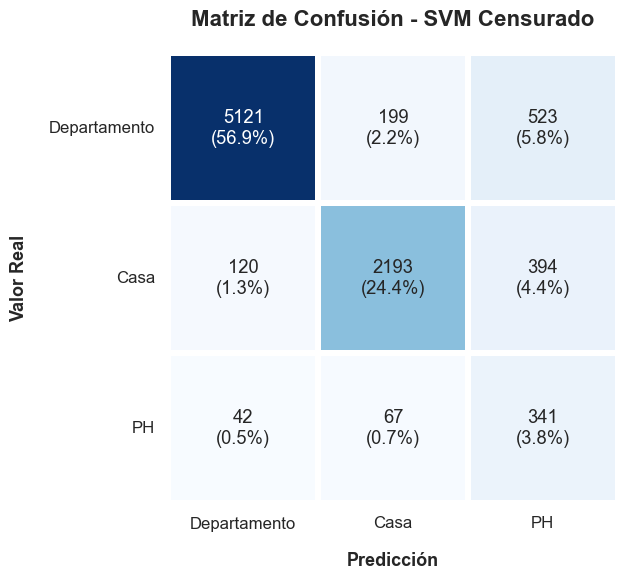

=== Modelo Naive Bayes Censurado ===
              precision    recall  f1-score   support

        Casa     0.8195    0.7784    0.7984      2707
Departamento     0.9719    0.7589    0.8523      5843
          PH     0.1719    0.7133    0.2771       450

    accuracy                         0.7624      9000
   macro avg     0.6545    0.7502    0.6426      9000
weighted avg     0.8861    0.7624    0.8073      9000



,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,0.7624,0.6545,0.7502,0.6426,0.8861,0.7624,0.8073


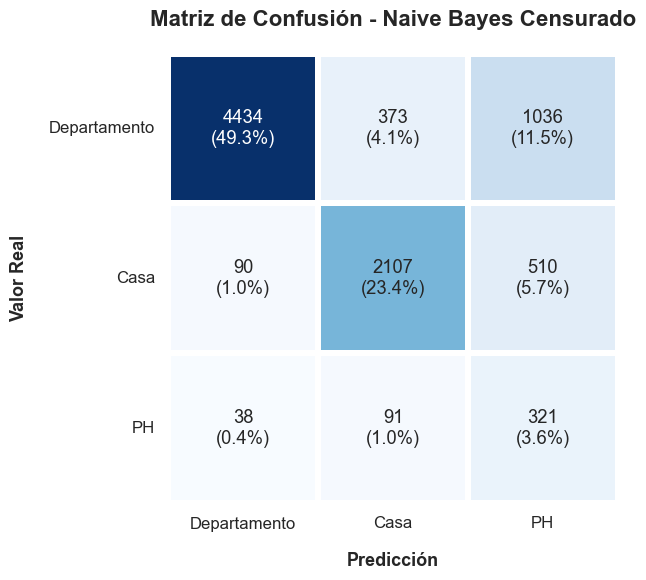

=== Modelo Regresión Logística Censurada ===
              precision    recall  f1-score   support

        Casa     0.9021    0.8201    0.8591      2707
Departamento     0.9720    0.8850    0.9265      5843
          PH     0.2830    0.7667    0.4134       450

    accuracy                         0.8596      9000
   macro avg     0.7190    0.8239    0.7330      9000
weighted avg     0.9165    0.8596    0.8806      9000



,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,0.8596,0.719,0.8239,0.733,0.9165,0.8596,0.8806


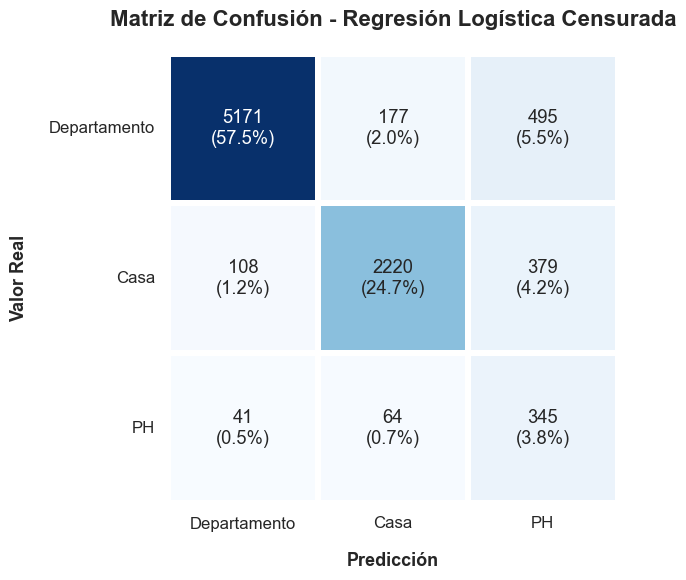

In [35]:
from src.property_text_pipeline import COLUMNA_TEXTO_LIMPIO_CENSURADO

# SVM Censurado
print("=== Modelo SVM Censurado ===")
modelo_svm_censurado = entrenar_modelo_base_svm(
    df_entrenamiento,
    df_entrenamiento[COLUMNA_OBJETIVO],
    columna_texto=COLUMNA_TEXTO_LIMPIO_CENSURADO,
)
predicciones_svm_censurado = modelo_svm_censurado.predict(df_prueba[COLUMNA_TEXTO_LIMPIO_CENSURADO])
print(construir_reporte_clasificacion(df_prueba[COLUMNA_OBJETIVO], predicciones_svm_censurado))
display(construir_tabla_metricas(df_prueba[COLUMNA_OBJETIVO], predicciones_svm_censurado))
dibujar_matriz_confusion_profesional(
    df_prueba[COLUMNA_OBJETIVO],
    predicciones_svm_censurado,
    etiquetas_ordenadas=['Departamento', 'Casa', 'PH'],
    titulo='Matriz de Confusión - SVM Censurado'
)

# Naive Bayes Censurado
print("=== Modelo Naive Bayes Censurado ===")
modelo_bayes_censurado = entrenar_modelo_bayes(
    df_entrenamiento,
    df_entrenamiento[COLUMNA_OBJETIVO],
    columna_texto=COLUMNA_TEXTO_LIMPIO_CENSURADO,
)
predicciones_bayes_censurado = modelo_bayes_censurado.predict(df_prueba[COLUMNA_TEXTO_LIMPIO_CENSURADO])
print(construir_reporte_clasificacion(df_prueba[COLUMNA_OBJETIVO], predicciones_bayes_censurado))
display(construir_tabla_metricas(df_prueba[COLUMNA_OBJETIVO], predicciones_bayes_censurado))
dibujar_matriz_confusion_profesional(
    df_prueba[COLUMNA_OBJETIVO],
    predicciones_bayes_censurado,
    etiquetas_ordenadas=['Departamento', 'Casa', 'PH'],
    titulo='Matriz de Confusión - Naive Bayes Censurado'
)

# Regresion Logistica Censurada
print("=== Modelo Regresión Logística Censurada ===")
modelo_logistica_censurado = entrenar_modelo_logistica(
    df_entrenamiento,
    df_entrenamiento[COLUMNA_OBJETIVO],
    columna_texto=COLUMNA_TEXTO_LIMPIO_CENSURADO,
)
predicciones_logistica_censurado = modelo_logistica_censurado.predict(df_prueba[COLUMNA_TEXTO_LIMPIO_CENSURADO])
print(construir_reporte_clasificacion(df_prueba[COLUMNA_OBJETIVO], predicciones_logistica_censurado))
display(construir_tabla_metricas(df_prueba[COLUMNA_OBJETIVO], predicciones_logistica_censurado))
dibujar_matriz_confusion_profesional(
    df_prueba[COLUMNA_OBJETIVO],
    predicciones_logistica_censurado,
    etiquetas_ordenadas=['Departamento', 'Casa', 'PH'],
    titulo='Matriz de Confusión - Regresión Logística Censurada'
)